# Mohr-Coulomb Long Adam Plateau Training

This notebook is the long-running training version of the surrogate example. It keeps the same basic workflow as the short demo, but switches to a much larger Adam run:

- `10000` Adam epochs maximum,
- `ReduceLROnPlateau` scheduler,
- plateau factor `0.5`,
- scheduler patience `100`,
- early-stopping patience `100`,
- progress printed every `100` epochs.

This is intentionally not the quick notebook. It is meant as a heavier optimization example.

## Environment setup

Resolve the repository root, add `src/` to the import path, and define output locations for the generated data, run directory, and evaluation plots.

In [9]:
from pathlib import Path
import json
import random
import sys

import numpy as np
import torch

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUTPUT_ROOT = ROOT / "notebook_runs" / "long_plateau_adam"
DATA_PATH = OUTPUT_ROOT / "mc_long_plateau.h5"
RUN_DIR = OUTPUT_ROOT / "principal_long_plateau"
EVAL_DIR = RUN_DIR / "eval"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Repository root: {ROOT}")
print(f"Torch device: {device}")
print(f"Outputs: {OUTPUT_ROOT}")

Repository root: /home/beremi/repos/mohr_coulomb_NN
Torch device: cuda
Outputs: /home/beremi/repos/mohr_coulomb_NN/notebook_runs/long_plateau_adam


## 1. Generate a focused training dataset

This uses the same focused parameter window and principal-strain cap that produced the stable demo dataset, but with a larger sample count so the long Adam run has more data to work with.

In [10]:
import h5py

from mc_surrogate.data import dataset_summary
from mc_surrogate.sampling import DatasetGenerationConfig, MaterialRangeConfig, generate_branch_balanced_dataset

material_ranges = MaterialRangeConfig(
    cohesion_range=(5.0, 25.0),
    friction_deg_range=(25.0, 45.0),
    dilatancy_deg_range=(0.0, 10.0),
    young_range=(1.0e4, 6.0e4),
    poisson_range=(0.25, 0.38),
    strength_reduction_range=(0.9, 2.0),
)

dataset_cfg = DatasetGenerationConfig(
    n_samples=10000,
    seed=seed,
    candidate_batch=1536,
    include_tangent=False,
    max_abs_principal_strain=2.0e-3,
    material_ranges=material_ranges,
)

branch_counts = generate_branch_balanced_dataset(str(DATA_PATH), dataset_cfg)
summary = dataset_summary(DATA_PATH)
with h5py.File(DATA_PATH, "r") as f:
    rowmax_stress = np.max(np.abs(f["stress"][:]), axis=1)

print("Branch counts:")
print(json.dumps(branch_counts, indent=2))
print("\nDataset summary:")
print(json.dumps(summary, indent=2))
print("\nStress max-abs quantiles:")
print(np.quantile(rowmax_stress, [0.0, 0.5, 0.9, 0.99, 1.0]))

Branch counts:
{
  "elastic": 2000,
  "smooth": 2000,
  "left_edge": 2000,
  "right_edge": 2000,
  "apex": 2000
}

Dataset summary:
{
  "path": "/home/beremi/repos/mohr_coulomb_NN/notebook_runs/long_plateau_adam/mc_long_plateau.h5",
  "n_samples": 10000,
  "contains_tangent": false,
  "branch_names": [
    "elastic",
    "smooth",
    "left_edge",
    "right_edge",
    "apex"
  ],
  "raw_material_columns": [
    "c0",
    "phi_deg",
    "psi_deg",
    "young",
    "poisson",
    "strength_reduction",
    "davis_id"
  ],
  "reduced_material_columns": [
    "c_bar",
    "sin_phi",
    "shear",
    "bulk",
    "lame"
  ],
  "split_counts": {
    "train": 8000,
    "val": 1000,
    "test": 1000
  },
  "branch_counts": {
    "elastic": 2000,
    "smooth": 2000,
    "left_edge": 2000,
    "right_edge": 2000,
    "apex": 2000
  }
}

Stress max-abs quantiles:
[2.50952310e-03 8.73519520e+00 2.07440180e+01 3.53649054e+01
 1.32331229e+02]


## 2. Configure the larger network and long Adam run

This cell sets up the larger principal-stress network and the long plateau-based Adam schedule. The trainer will print status every `100` epochs.

In [11]:
from mc_surrogate.models import build_model
from mc_surrogate.training import TrainingConfig

config = TrainingConfig(
    dataset=str(DATA_PATH),
    run_dir=str(RUN_DIR),
    model_kind="principal",
    epochs=10000,
    batch_size=2048,
    lr=1.0e-3,
    weight_decay=5.0e-5,
    width=512,
    depth=8,
    dropout=0.0,
    seed=seed,
    patience=1000,
    grad_clip=1.0,
    branch_loss_weight=0.05,
    num_workers=0,
    device=device,
    scheduler_kind="plateau",
    min_lr=1.0e-6,
    plateau_factor=0.5,
    plateau_patience=100,
    lbfgs_epochs=0,
    log_every_epochs=100,
)

model = build_model(
    model_kind=config.model_kind,
    input_dim=11,
    width=config.width,
    depth=config.depth,
    dropout=config.dropout,
)
n_params = sum(p.numel() for p in model.parameters())

print(model)
print(f"\nTrainable parameters: {n_params:,}")
print("\nTraining configuration:")
print(json.dumps(config.__dict__, indent=2))

PrincipalStressNet(
  (input): Sequential(
    (0): Linear(in_features=11, out_features=512, bias=True)
    (1): GELU(approximate='none')
  )
  (blocks): ModuleList(
    (0-7): 8 x ResidualBlock(
      (net): Sequential(
        (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=512, out_features=512, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.0, inplace=False)
        (4): Linear(in_features=512, out_features=512, bias=True)
      )
      (out_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (act): GELU(approximate='none')
    )
  )
  (head_stress): Linear(in_features=512, out_features=3, bias=True)
  (head_branch): Linear(in_features=512, out_features=5, bias=True)
)

Trainable parameters: 4,229,128

Training configuration:
{
  "dataset": "/home/beremi/repos/mohr_coulomb_NN/notebook_runs/long_plateau_adam/mc_long_plateau.h5",
  "run_dir": "/home/beremi/repos/mohr_coulomb_NN/notebook_runs/long_pla

## 3. Train the surrogate

This runs the long Adam training schedule. Training stops when either `10000` epochs are reached or validation loss fails to improve for `100` epochs. The trainer prints one progress line every `100` epochs.

In [12]:
from mc_surrogate.training import train_model

train_summary = train_model(config)
print(json.dumps(train_summary, indent=2))

[Adam] epoch=1 lr=1.000e-03 train_loss=1.051286 val_loss=0.407249 train_stress_mse=32.156859 val_stress_mse=10.948463 best_val=0.407249
[Adam] epoch=100 lr=1.000e-03 train_loss=0.046393 val_loss=0.046495 train_stress_mse=1.219657 val_stress_mse=1.070686 best_val=0.036091
[Adam] epoch=200 lr=1.000e-03 train_loss=0.036526 val_loss=0.039976 train_stress_mse=0.919391 val_stress_mse=0.901613 best_val=0.034731
[Adam] epoch=300 lr=5.000e-04 train_loss=0.034602 val_loss=0.035726 train_stress_mse=0.874616 val_stress_mse=0.889185 best_val=0.033690
[Adam] epoch=400 lr=5.000e-04 train_loss=0.034094 val_loss=0.033663 train_stress_mse=0.863341 val_stress_mse=0.837406 best_val=0.033270
[Adam] epoch=500 lr=5.000e-04 train_loss=0.034530 val_loss=0.033154 train_stress_mse=0.871130 val_stress_mse=0.827451 best_val=0.033143
[Adam] epoch=600 lr=5.000e-04 train_loss=0.036730 val_loss=0.035556 train_stress_mse=0.930422 val_stress_mse=0.898696 best_val=0.033078
[Adam] epoch=700 lr=2.500e-04 train_loss=0.03353

## 4. Visualize and validate

Once training finishes, evaluate the best checkpoint, save plots, and compare it on a representative triaxial loading path.

{
  "split": "test",
  "n_samples": 1000,
  "stress_mae": 0.7155188778779933,
  "stress_rmse": 0.9648700527790411,
  "stress_max_abs": 5.054168592531795,
  "per_component_mae": [
    0.7507793749653395,
    0.7788312803110037,
    0.7857911418860787,
    0.6473349085517793,
    0.6744108599129542,
    0.6559657016408046
  ],
  "principal_mae": 1.2402238990368837,
  "principal_rmse": 1.6281638851239015,
  "branch_accuracy": 0.999,
  "branch_confusion": [
    [
      211,
      0,
      0,
      0,
      0
    ],
    [
      0,
      193,
      1,
      0,
      0
    ],
    [
      0,
      0,
      203,
      0,
      0
    ],
    [
      0,
      0,
      0,
      191,
      0
    ],
    [
      0,
      0,
      0,
      0,
      201
    ]
  ],
  "per_branch_stress_mae": {
    "elastic": 0.938781809725295,
    "smooth": 0.3426585512150166,
    "left_edge": 0.6112262365484334,
    "right_edge": 0.7112480113249441,
    "apex": 0.9504122433226194
  }
}

Metrics saved to: /home/beremi/re

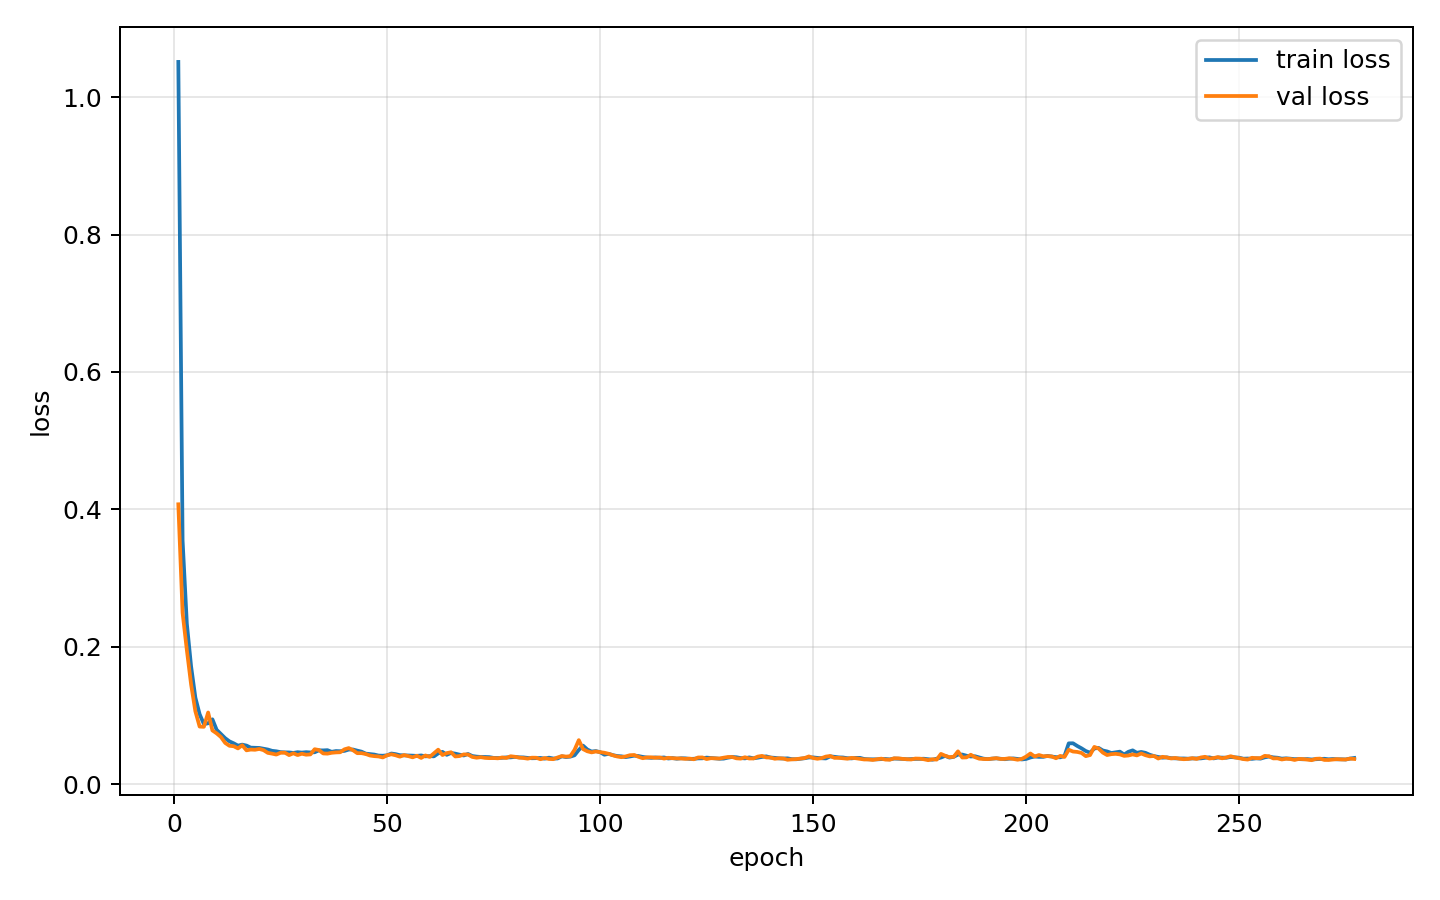

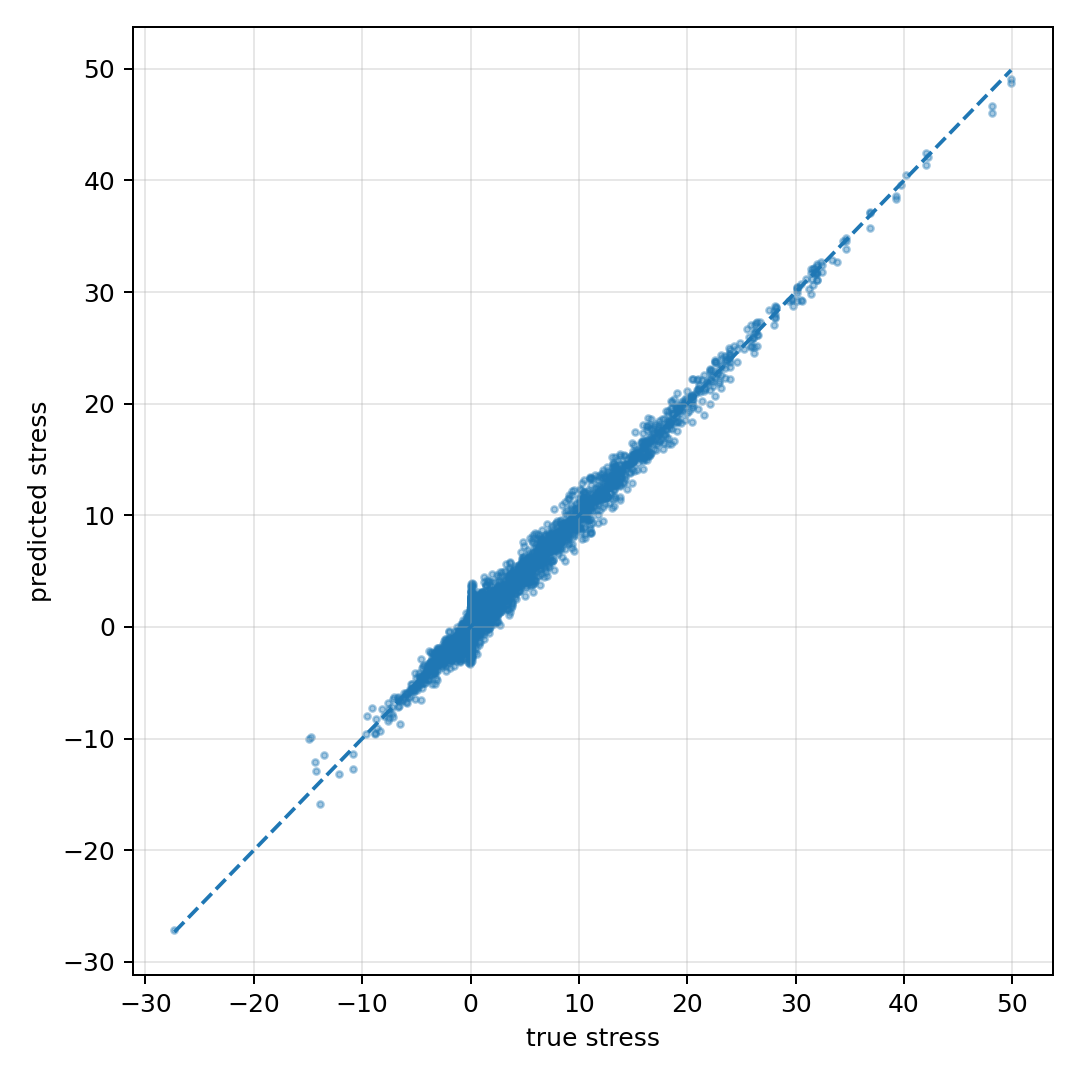

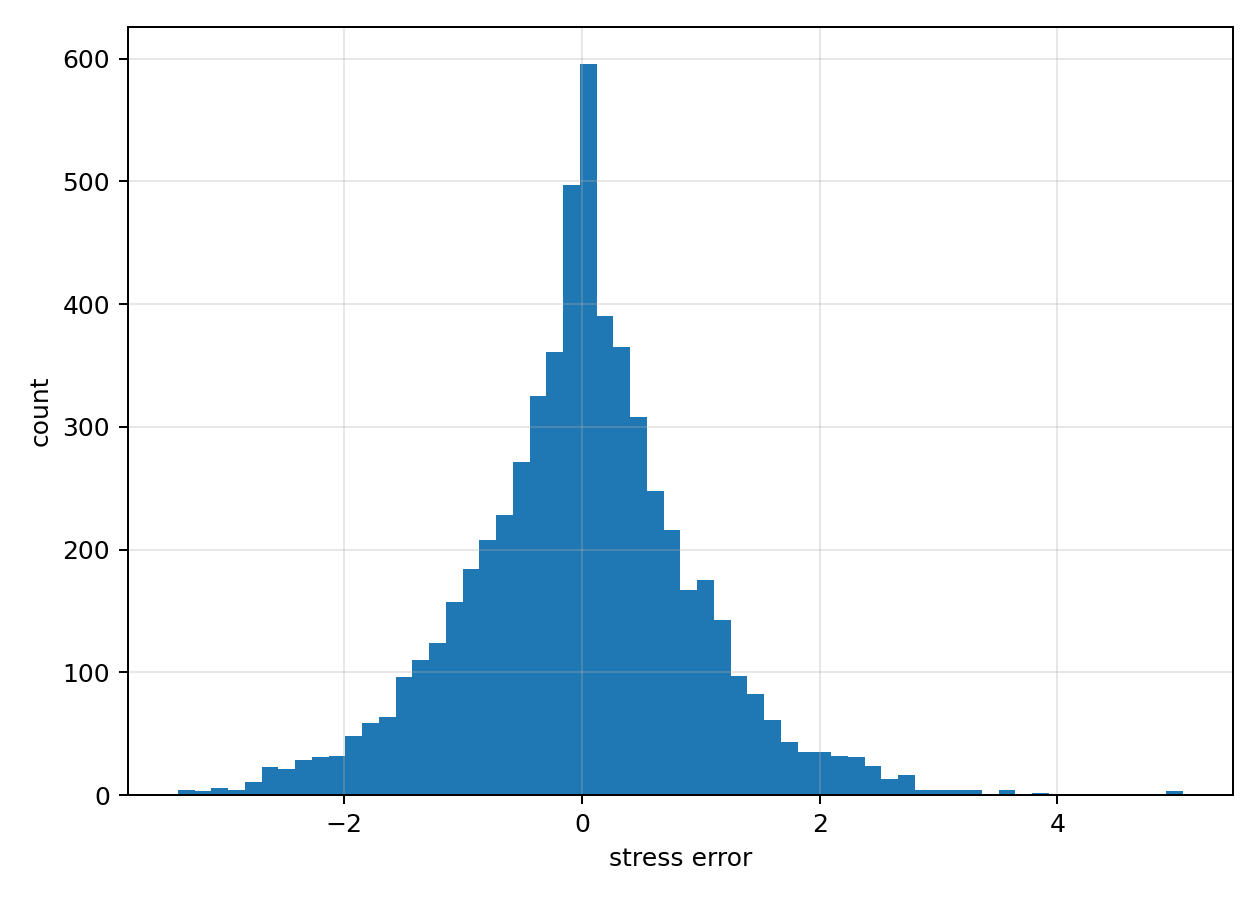

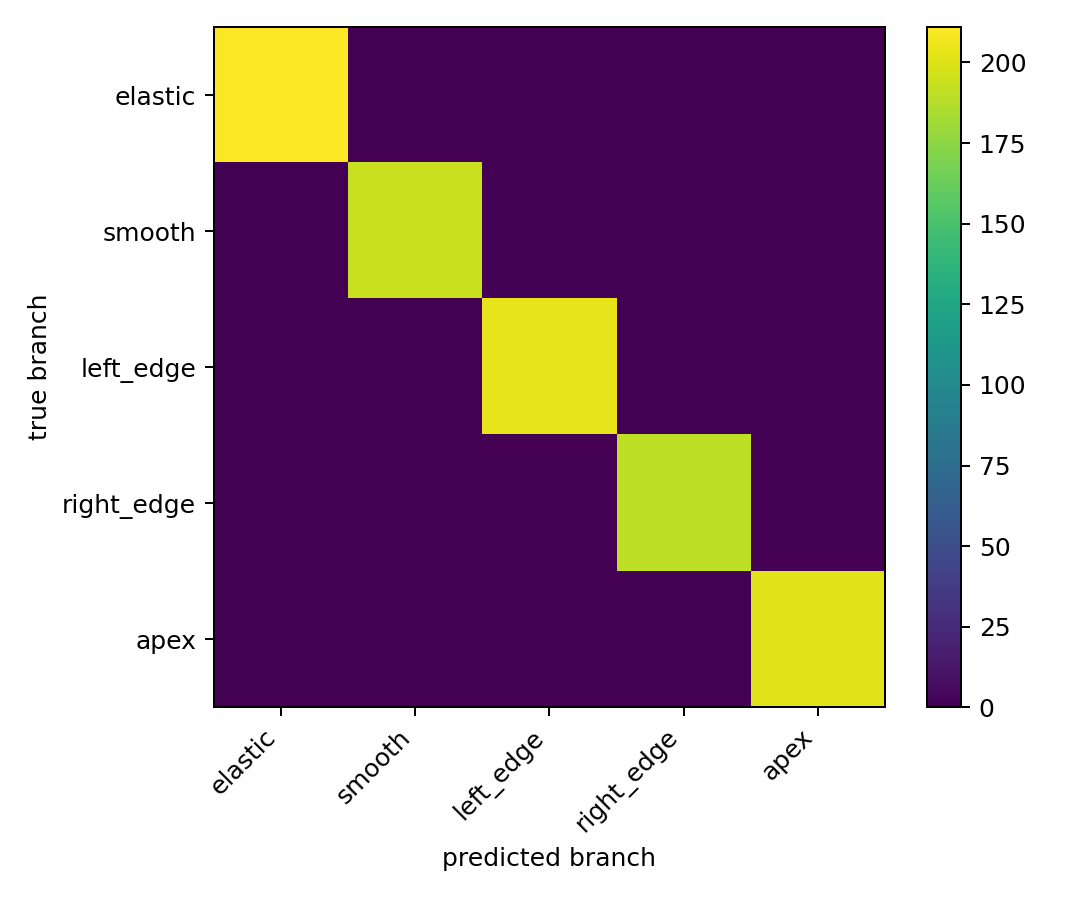

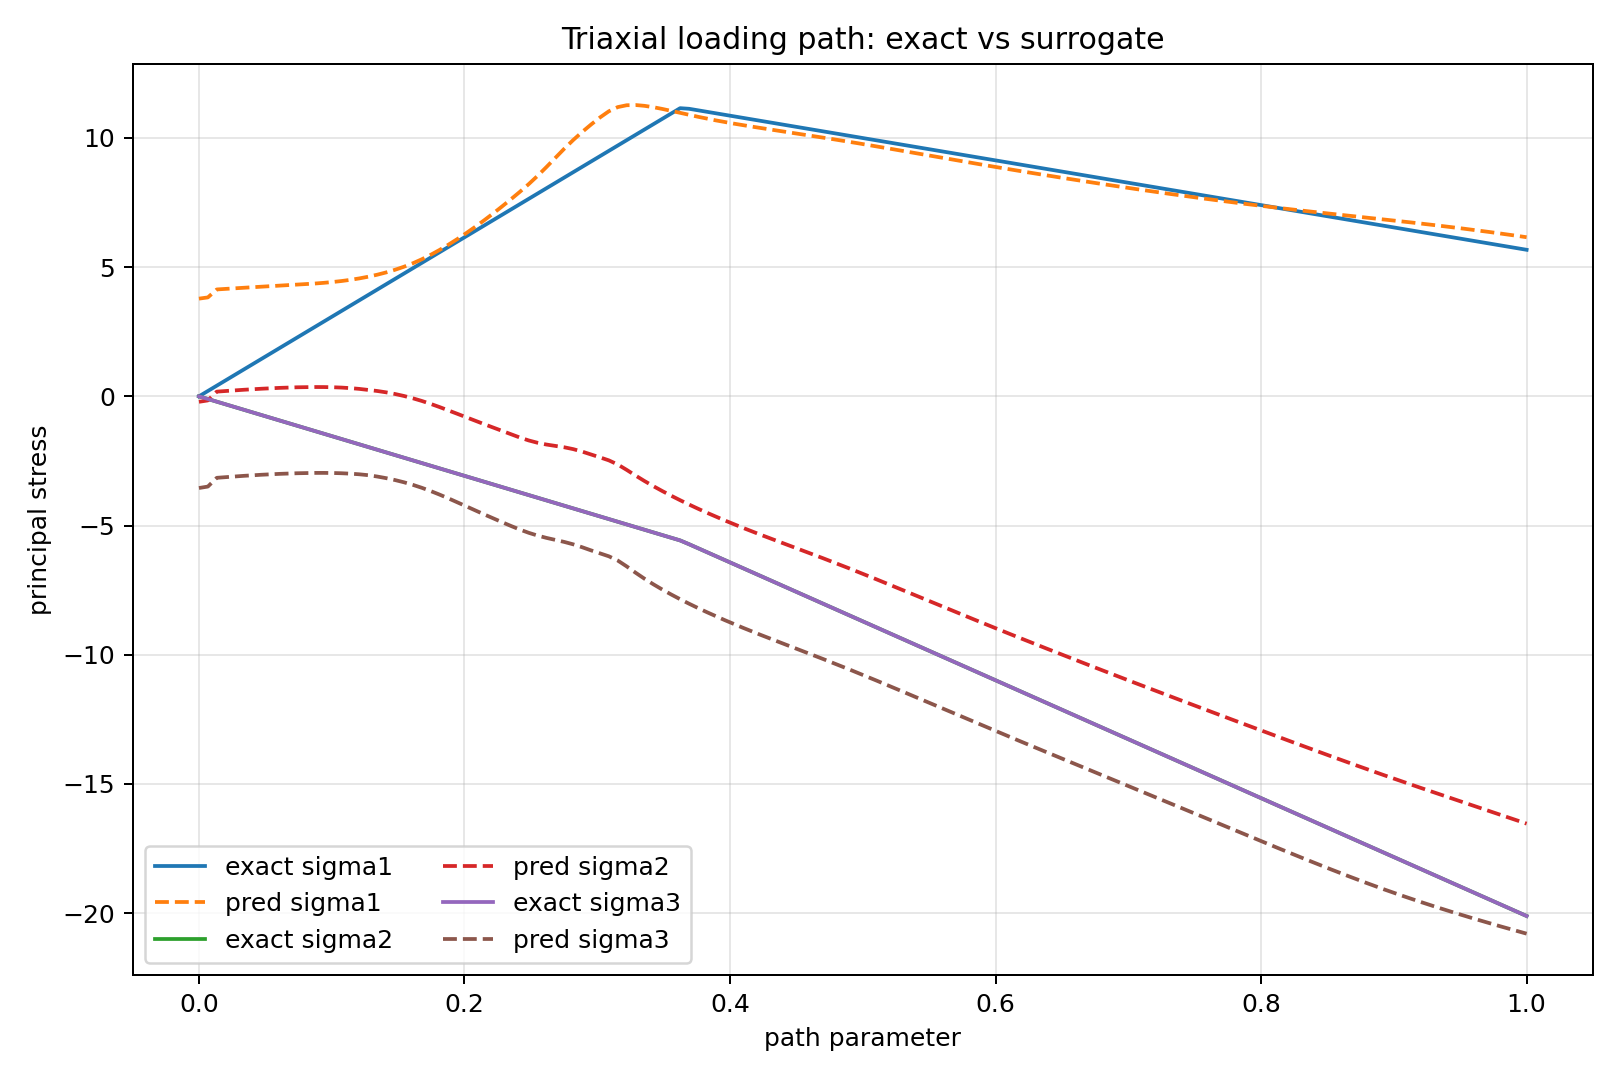

In [5]:
from IPython.display import Image, display

from mc_surrogate.inference import ConstitutiveSurrogate
from mc_surrogate.materials import build_reduced_material_from_raw
from mc_surrogate.mohr_coulomb import constitutive_update_3d
from mc_surrogate.training import evaluate_checkpoint_on_dataset
from mc_surrogate.viz import (
    branch_confusion_plot,
    error_histogram,
    parity_plot,
    plot_path_comparison,
    plot_training_history,
    save_metrics_json,
)
from mc_surrogate.voigt import tensor_to_strain_voigt

history_png = plot_training_history(RUN_DIR / "history.csv", EVAL_DIR / "history.png")

result = evaluate_checkpoint_on_dataset(
    checkpoint_path=RUN_DIR / "best.pt",
    dataset_path=DATA_PATH,
    split="test",
    device=device,
)

metrics = result["metrics"]
arrays = result["arrays"]
pred = result["predictions"]

metrics_json = save_metrics_json(metrics, EVAL_DIR / "metrics.json")
parity_png = parity_plot(arrays["stress"], pred["stress"], EVAL_DIR / "parity_stress.png", label="stress")
error_png = error_histogram(pred["stress"] - arrays["stress"], EVAL_DIR / "stress_error_hist.png", label="stress error")

branch_png = None
if "branch_confusion" in metrics:
    branch_png = branch_confusion_plot(metrics["branch_confusion"], EVAL_DIR / "branch_confusion.png")

t = np.linspace(0.0, 1.0, 150)
principal_strain = np.column_stack([2.0 * t, -1.0 * t, -1.0 * t]) * 1.0e-3
rotations = np.repeat(np.eye(3)[None, :, :], t.size, axis=0)
strain_eng = tensor_to_strain_voigt(np.einsum("nij,nj,nkj->nik", rotations, principal_strain, rotations))

reduced = build_reduced_material_from_raw(
    c0=np.full(t.size, 15.0),
    phi_rad=np.deg2rad(np.full(t.size, 35.0)),
    psi_rad=np.deg2rad(np.full(t.size, 0.0)),
    young=np.full(t.size, 2.0e4),
    poisson=np.full(t.size, 0.30),
    strength_reduction=np.full(t.size, 1.2),
    davis_type=["B"] * t.size,
)

exact = constitutive_update_3d(
    strain_eng,
    c_bar=reduced.c_bar,
    sin_phi=reduced.sin_phi,
    shear=reduced.shear,
    bulk=reduced.bulk,
    lame=reduced.lame,
)
surrogate = ConstitutiveSurrogate.from_checkpoint(RUN_DIR / "best.pt", device=device)
path_pred = surrogate.predict_reduced(
    strain_eng,
    c_bar=reduced.c_bar,
    sin_phi=reduced.sin_phi,
    shear=reduced.shear,
    bulk=reduced.bulk,
    lame=reduced.lame,
)
path_png = plot_path_comparison(
    t,
    exact.stress_principal,
    path_pred["stress_principal"],
    EVAL_DIR / "path_comparison.png",
    title="Triaxial loading path: exact vs surrogate",
)

print(json.dumps(metrics, indent=2))
print(f"\nMetrics saved to: {metrics_json}")

for image_path in [history_png, parity_png, error_png, branch_png, path_png]:
    if image_path is not None:
        display(Image(filename=image_path))